# Two-Layer Grid

In [1]:
using DifferentialEquations
using LightGraphs
using GraphRecipes
using Statistics
using LaTeXStrings
using Plots
using LinearAlgebra
using Plotly

HTML{String}("<script>\n// Immediately-invoked-function-expression to avoid global variables.\n(function() {\n    var warning_div = document.getElementById(\"webio-warning-9403432618138629625\");\n    var hide = function () {\n        var script = document.getElementById(\"webio-setup-13524321548141344687\");\n        var parent = script && script.parentElement;\n        var grandparent = parent && parent.parentElement;\n        if (grandparent) {\n            grandparent.style.display = \"none\";\n        }\n        warning_div.style.display = \"none\";\n    };\n    if (typeof Jupyter !== \"undefined\") {\n        console.log(\"WebIO detected Jupyter notebook environment.\");\n        // Jupyter notebook.\n        var extensions = (\n            Jupyter\n            && Jupyter.notebook.config.data\n            && Jupyter.notebook.config.data.load_extensions\n        );\n        if (extensions && extensions[\"webio-jupyter-notebook\"]) {\n            // Extension already loaded.\n            console.log(\"Jupyter WebIO nbextension detected; not loading ad-hoc.\");\n            hide();\n            return;\n        }\n    } else if (window.location.pathname.includes(\"/lab\")) {\n        // Guessing JupyterLa\n        console.log(\"Jupyter Lab detected; make sure the @webio/jupyter-lab-provider labextension is installed.\");\n        hide();\n        return;\n    }\n})();\n\n</script>\n<p\n    id=\"webio-warning-9403432618138629625\"\n    class=\"output_text output_stderr\"\n    style=\"padding: 1em; font-weight: bold;\"\n>\n    Unable to load WebIO. Please make sure WebIO works for your Jupyter client.\n    For troubleshooting, please see <a href=\"https://juliagizmos.github.io/WebIO.jl/latest/providers/ijulia/\">\n    the WebIO/IJulia documentation</a>.\n    <!-- TODO: link to installation docs. -->\n</p>\n")

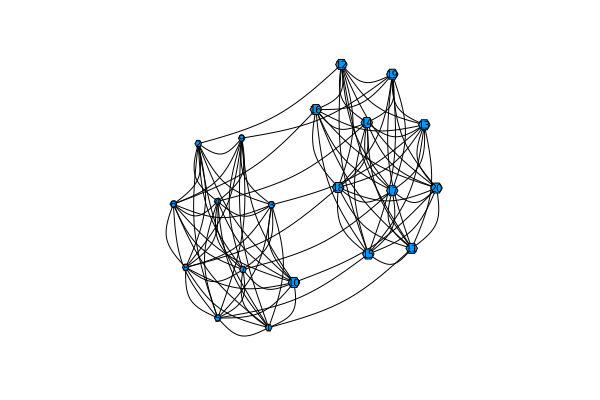

In [2]:
g1=CompleteGraph(20)
int=Int(nv(g1)/2)
for i in 1:int
    for j in (int+1):Int(2*int)
        rem_edge!(g1,i,j)
    end
    add_edge!(g1,i,int+i)
end
graphplot(g1,names=1:20)

In [3]:
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [31]:
function r2N(grid,sol,tspan)
    N=Int(nv(grid))
    Δt=tspan[2]-tspan[1]
    leng=length(sol[1,1:end])
    A=[exp.(sol[i,1:end].*im) for i in 1:N]
    B=zeros(leng)
    for i in 1:N
        B=B.+A[i]
    end
    return (1/Δt)*sum(abs2.((1/N)*B)*Δt/(leng-1))
end

r2N (generic function with 2 methods)

# Kuramoto Model

In [49]:
function soltnN(grid,w,k,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+(k/n)*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        int=Int(n/2)
        C=ρ*ones(n,n)
        C[diagind(C)] .= 1
        for i in 1:int
            C[(int+1):end,i]=ρ*ones(int)
        end
        for i in (int+1):n
            C[1:int,i]=ρ*ones(int)
        end
        G=(σ/sqrt(2))*G_generate(C)
        du.=G
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(n,n))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

soltnN (generic function with 1 method)

In [50]:
#Kuramoto Data with rho covariance
w=vcat(-(1/2)*ones(10),(1/2)*ones(10))
tf=5000.0
u0=rand(20)
e(k)=r2N(g1,soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
f(k)=r2N(g1,soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),-0.5),(0.0,tf))
g(k)=r2N(g1,soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
h(k)=r2N(g1,soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),0.5),(0.0,tf))
i(k)=r2N(g1,soltnN(g1,w,k,u0,(0.0,tf),sqrt(2),1),(0.0,tf))
ks=LinRange(0,3,150)
edat2=e.(ks)
fdat2=f.(ks)
gdat2=g.(ks)
hdat2=h.(ks)
idat2=i.(ks)

150-element Array{Float64,1}:
 0.5269995435504381
 0.5022266778669333
 0.5029716311860475
 0.503902657834633
 0.5045241674128813
 0.5046170535887388
 0.5054529045477036
 0.5055593511525617
 0.5059872991893952
 0.5063027242440631
 0.5062433138165466
 0.5062720198304809
 0.5064198189468206
 ⋮
 0.9666352820678317
 0.967106299370236
 0.9675761089209431
 0.96805727149569
 0.9685858158550038
 0.9689882913083819
 0.9694469935069527
 0.969880694443167
 0.9703072653716598
 0.9706911957774599
 0.9711194250739086
 0.9715213928891193

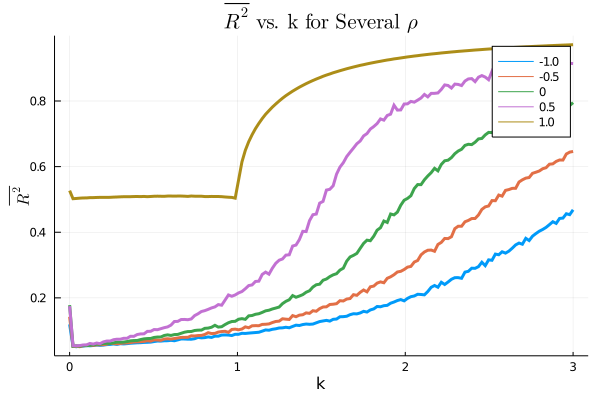

In [52]:
Plots.plot(ks,[edat2,fdat2,gdat2,hdat2,idat2],title= L"\overline{R^2} \textrm{ vs. k for Several ρ}",label=["-1.0" "-0.5" "0" "0.5" "1.0"],xlabel="k",ylabel=L"\overline{R^2}",width=3)

# Swing Equation

In [38]:
function swingsoltnN(grid,D,B,P,M,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        du[1:n]=u[n+1:2n]
        du[n+1:2n] = (-D.*u[n+1:2n] - E*((B/n).*sin.(E'*u[1:n])) + P)./M 
    end
    
    function g(du,u,p,t)
        A=zeros(2n,2n)
        int=Int(nv(g1)/2)
        C=ones(n,n)
        for i in 1:int
            C[(int+1):end,i]=ρ*ones(int)
        end
        for i in (int+1):nv(g1)
            C[1:int,i]=ρ*ones(int)
        end
        G=(σ/sqrt(2))*G_generate(C)
        for i in 1:n
            A[n+i,1:2n]=vcat(zeros(n),G[i,1:n])
        end
        du.=A
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(2n,2n))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

swingsoltnN (generic function with 1 method)